# Volume 4 Modeling Project Associated Code
    Brandon, Cole, Josh, Matt, and Nathan

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import minimize
import pandas as pd
from matplotlib import dates
import sympy as sp
plt.rcParams['figure.facecolor'] = 'white'  # Figure background
plt.rcParams['axes.facecolor'] = 'white'   # Axes background
plt.rcParams['figure.dpi'] = 100

In [2]:
def first_model():

    #Define the ODE and carrying capacity
    K = 2/3
    alpha_values = np.random.rand(5)
    beta_values = np.random.rand(5, 5)
    
    #Define the ODE
    def ode(t, y):
        dydt = np.zeros(5)
        
        # Define the ODE
        for i in range(5):
            dydt[i] = y[i] * (alpha_values[i] * (1 - y[i] / K) - np.sum([beta_values[i, j] * y[j] for j in range(5) if j != i]))
        return dydt

    #Define the time and space
    t0 = 0
    tf = 120
    x_space = np.linspace(0, tf, 1000)
    
    #Define y0 and solution
    y0 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    sol = solve_ivp(ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    
    #Plot the system
    plt.plot(x_space, sol.y[0],  label='Company 1, alpha = ' + str(alpha_values[0]))
    plt.plot(x_space, sol.y[1],  label='Company 2, alpha = ' + str(alpha_values[1]))
    plt.plot(x_space, sol.y[2],  label='Company 3, alpha = ' + str(alpha_values[2]))
    plt.plot(x_space, sol.y[3],  label='Company 4, alpha = ' + str(alpha_values[3]))
    plt.plot(x_space, sol.y[4],  label='Company 5, alpha = ' + str(alpha_values[4]))
    plt.ylabel("Proportion of Population")
    plt.legend(loc='upper right')
    plt.xlabel("T (days)")
    plt.title("First Model Test:")
    plt.ylim(0, 1)
    plt.show()

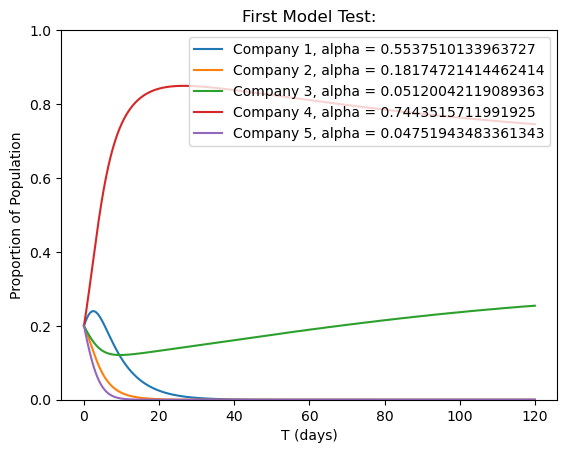

In [3]:
first_model()

# Shock Models

# Company Scandal

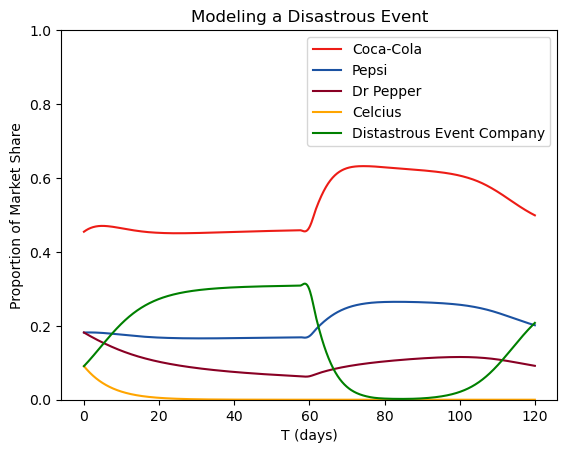

In [4]:
def event_based_model():
    
    #Define the ODE and carrying capacity
    K = 2/3
    alpha_values = np.array([0.5, 0.4, 0.35, 0.2, 0.5])
    beta_values = np.array([[0.5, -0.1, 0.3, 0.3, 0.3],
                            [0.3, 0.5, 0.3, 0.3, 0.3],
                            [0.3, 0.3, 0.5, 0.3, 0.3],
                            [0.3, 0.3, 0.3, 0.5, 0.3],
                            [0.3, 0.3, 0.3, 0.3, 0.3]])    
    
    #Define the ODE
    def ode(t, y):
        dydt = np.zeros(5)

        # Event: Company 3 (index 2) performs poorly between t=60 and t=75
        temporary_alpha = alpha_values.copy()
        if 60 <= t <= 75:
            temporary_alpha[4] *= 0.1
            
        # Bring the rate back up linearly between t=75 and t=90
        if 75 <= t <= 90:
            temporary_alpha[4] *= 0.1 * 10 * (t - 75) / 15

        # Adjust the other alpha and beta values
        for i in range(5):
            competitive_term = np.sum([beta_values[i, j] * y[j] for j in range(5) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
        return dydt

    #Define the time and space
    t0 = 0
    tf = 120
    x_space = np.linspace(0, tf, 1000)
    
    #Define y0 and solution
    y0 = np.array([0.5, 0.2, 0.2, 0.1, 0.1])
    sol = solve_ivp(ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    
    #Plot the system
    plt.plot(x_space, sol.y[0],  label='Coca-Cola', color='#ed1c16')
    plt.plot(x_space, sol.y[1],  label='Pepsi', color='#1b52a2')
    plt.plot(x_space, sol.y[2],  label='Dr Pepper', color='#890024')
    plt.plot(x_space, sol.y[3],  label='Celcius', color='orange')
    plt.plot(x_space, sol.y[4],  label="Distastrous Event Company", color='green')
    plt.ylabel("Proportion of Market Share")
    plt.xlabel("T (days)")
    plt.title("Modeling a Disastrous Event")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    
event_based_model()

When a company experiences significant losses due to a public incident, such as a scandal or sudden negative news, its market share is likely to decline, at least temporarily. This drop can result from negative public opinion, financial or operational setbacks, or declining stock prices. In the model above, the company’s growth rate was sharply reduced for a period, reflecting the time it may take to recover from such an event, which could span months or even years. Meanwhile, the other companies in the market experienced slight increases in their market share, highlighting how such incidents can create opportunities for competitors to gain an advantage.

# Entering Competitor

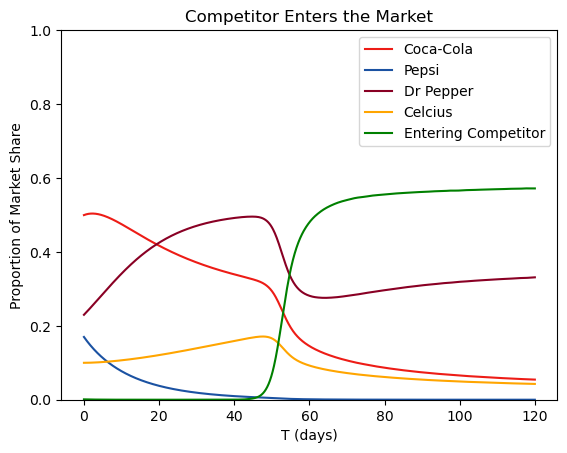

In [5]:
def event_based_model():
    
    #Define the ODE and carrying capacity
    K = 2/3
    alpha_values = np.array([0.3, 0.2, 0.4, 0.3, 0.0001])
    beta_values = np.array([[0.5, -0.1, 0.3, 0.3, 0.3],
                            [0.3, 0.5, 0.3, 0.3, 0.3],
                            [0.3, 0.3, 0.5, 0.3, 0.3],
                            [0.3, 0.3, 0.3, 0.5, 0.3],
                            [0.3, 0.3, 0.3, 0.3, 0.3]])    
    
    #Define the ODE
    def ode(t, y):
        
        # Define the ODE
        dydt = np.zeros(5)
        temporary_alpha = alpha_values.copy()
        if t > 30:
            temporary_alpha[4] =  0.9
        
        # Adjust the other alpha and beta values
        for i in range(5):
            competitive_term = np.sum([beta_values[i, j] * y[j] for j in range(5) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
        return dydt

    #Define the time and space
    t0 = 0
    tf = 120
    x_space = np.linspace(0, tf, 1000)
    
    #Define y0 and solution
    y0 = np.array([0.5, 0.17, 0.23, 0.1, 0.001])
    sol = solve_ivp(ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    
    #Plot the system
    plt.plot(x_space, sol.y[0],  label='Coca-Cola', color='#ed1c16')
    plt.plot(x_space, sol.y[1],  label='Pepsi', color='#1b52a2')
    plt.plot(x_space, sol.y[2],  label='Dr Pepper', color='#890024')
    plt.plot(x_space, sol.y[3],  label='Celcius', color='orange')
    plt.plot(x_space, sol.y[4],  label="Entering Competitor", color='green')
    plt.ylabel("Proportion of Market Share")
    plt.xlabel("T (days)")
    plt.title("Competitor Enters the Market")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    
event_based_model()

When a strong competitor enters the market with impactful marketing, such as viral backing or influencer endorsements, it can significantly disrupt the dynamics of the industry. As shown above, the relative market share of all existing companies declined at a similar rate, indicating that they collectively suffered losses due to the new entrant’s presence. Such events are becoming increasingly common with the rise of social media influencers and the potential for viral videos and trends to rapidly amplify a brand’s visibility and appeal.

# Merger / Acquisition

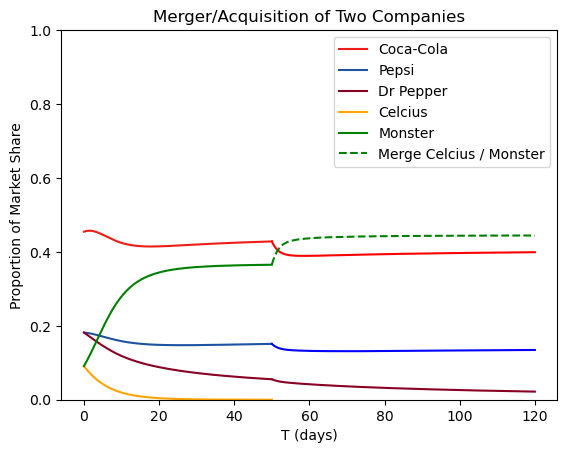

In [6]:
def event_based_model():
    
    #Define the alpha, beta, and k values
    K = 2/3
    alpha_values = np.array([0.5, 0.4, 0.35, 0.2, 0.6])
    beta_values = np.array([[0.5, -0.1, 0.3, 0.3, 0.3],
                            [0.3, 0.5, 0.3, 0.3, 0.3],
                            [0.3, 0.3, 0.5, 0.3, 0.3],
                            [0.3, 0.3, 0.3, 0.5, 0.3],
                            [0.3, 0.3, 0.3, 0.3, 0.3]])
    
    #Define the ODE
    def ode_premerger(t, y):
        
        # Define the ODE
        dydt = np.zeros(5)
        temporary_alpha = alpha_values.copy()
        
        # Make adjustments for the merger
        for i in range(5):
            competitive_term = np.sum([beta_values[i, j] * y[j] for j in range(5) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
        return dydt
    
    #Define the alpha, beta, and k values for the merger
    alpha_values_merger = np.array([0.5, 0.4, 0.35, 0.9])
    beta_values_merger = np.array([[0.5, -0.1, 0.3, 0.3],
                                    [0.3, 0.5, 0.3, 0.3],
                                    [0.3, 0.3, 0.5, 0.3],
                                    [0.3, 0.3, 0.3, 0.5]])
    
    #Define the ODE for the merger
    def ode_merger(t, y):
        dydt = np.zeros(4)
        temporary_alpha = alpha_values_merger.copy()  # Copy to modify for events

        # Adjust the alpha values for the merger
        for i in range(4):
            competitive_term = np.sum([beta_values_merger[i, j] * y[j] for j in range(4) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
        return dydt

    #Define the time and space for the premerger and merger
    t0 = 0
    tf = 50
    tf_merger = 120
    x_space_premerger = np.linspace(0, tf, 500)
    x_space_merger = np.linspace(tf, tf_merger, 500)
    
    #Define y0 and solution
    y0 = np.array([0.5, 0.2, 0.2, 0.1, 0.1])
    sol = solve_ivp(ode_premerger, (t0, tf), y0, t_eval=np.linspace(t0, tf, 500))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    y0_merger = np.ones(4)
    y0_merger[0] = sol.y[0][-1]
    y0_merger[1] = sol.y[1][-1]
    y0_merger[2] = sol.y[2][-1]
    y0_merger[3] = sol.y[3][-1] + sol.y[4][-1]
    sol_merger = solve_ivp(ode_merger, (tf, tf_merger), y0_merger, t_eval=np.linspace(tf, tf_merger, 500))
    sol_merger.y = sol_merger.y / np.sum(sol_merger.y, axis=0)
    
    #Plot the system
    plt.plot(x_space_premerger, sol.y[0],  label='Coca-Cola', color='#ed1c16')
    plt.plot(x_space_premerger, sol.y[1],  label='Pepsi', color='#1b52a2')
    plt.plot(x_space_premerger, sol.y[2],  label='Dr Pepper', color='#890024')
    plt.plot(x_space_premerger, sol.y[3],  label='Celcius', color='orange')
    plt.plot(x_space_premerger, sol.y[4],  label="Monster", color='green')
    plt.plot(x_space_merger, sol_merger.y[0], color='red')
    plt.plot(x_space_merger, sol_merger.y[1], color='blue')
    plt.plot(x_space_merger, sol_merger.y[2], color='#890024')
    plt.plot(x_space_merger, sol_merger.y[3],  label='Merge Celcius / Monster', color='green', linestyle='--')
    plt.ylabel("Proportion of Market Share")
    plt.xlabel("T (days)")
    plt.title("Merger/Acquisition of Two Companies")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    
event_based_model()

Companies are merged frequently. There will be merger events when a company will buy out a company to grow their own spread and net worth. In the example above, a strong company buys out an almost failed company and uses their rights and inventory to take advantage of the market. The result is indicated by a decrease proportional to company size. This is an interesting and common phenomena that can occur in many different market sectors. 

# Company Release of New Product

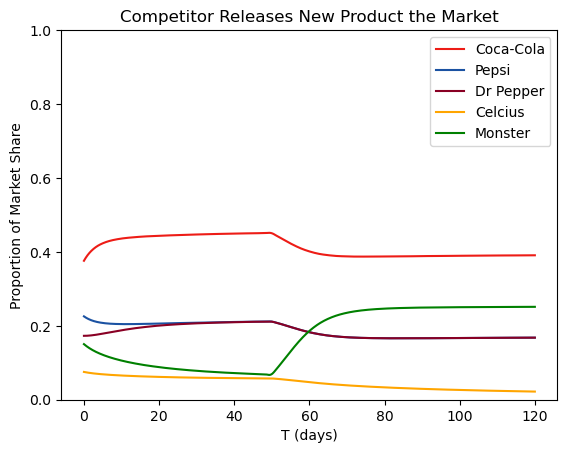

In [7]:
def event_based_model():

    #Define the ODE and carrying capacity    
    K = 2/3
    alpha_values = np.array([0.7, 0.5, 0.5, 0.4, 0.4])
    beta_values = np.array([[0.5, -0.1, 0.3, 0.3, 0.3],
                            [0.3, 0.5, 0.3, 0.3, 0.3],
                            [0.3, 0.3, 0.5, 0.3, 0.3],
                            [0.3, 0.3, 0.3, 0.5, 0.3],
                            [0.3, 0.3, 0.3, 0.3, 0.3]])    
    
    #Define the ODE
    def ode(t, y):
        
        # Initialize the values
        dydt = np.zeros(5)
        temporary_alpha = alpha_values.copy()

        # Start of the event
        if t > 50:
            temporary_alpha[4] =  0.6
            
        # Adjust the other alpha and beta values
        for i in range(5):
            competitive_term = np.sum([beta_values[i, j] * y[j] for j in range(5) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
            
        return dydt

    #Define the time and space
    t0 = 0
    tf = 120
    x_space = np.linspace(0, tf, 1000)
    
    #Define y0 and solution
    y0 = np.array([0.5, 0.3, 0.23, 0.1, 0.2])
    sol = solve_ivp(ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    
    #Plot the system
    plt.plot(x_space, sol.y[0],  label='Coca-Cola', color='#ed1c16')
    plt.plot(x_space, sol.y[1],  label='Pepsi', color='#1b52a2')
    plt.plot(x_space, sol.y[2],  label='Dr Pepper', color='#890024')
    plt.plot(x_space, sol.y[3],  label='Celcius', color='orange')
    plt.plot(x_space, sol.y[4],  label="Monster", color='green')
    plt.ylabel("Proportion of Market Share")
    plt.xlabel("T (days)")
    plt.title("Competitor Releases New Product the Market")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    
event_based_model()

# Data Collection

In [8]:
df = pd.read_feather("crsp_monthly.ftr")

# Filter the data to only include the companies of interest
df = df.query("ticker in ['KO', 'PEP', 'KDP', 'DPS', 'MNST','HANS' 'CELH']")
df['mktcap'] = df['prc'] * df['shr']

# Calculate the total market capitalization for each month
df['total_mktcap'] = df.groupby('caldt')['mktcap'].transform('sum')
df['rel_mktcap'] = df['mktcap'] / df['total_mktcap']

In [9]:
# Filter the data to only include the companies of interest
port = df.groupby(['caldt','ticker'])['rel_mktcap'].sum()
port = port.unstack(level=['ticker'])
port = port.query("caldt >= '2012-01'")
port.fillna(0, inplace=True)

# Adjust the data to be in the correct format
port2 = port.copy()

#create "Other company" which is the aggregate of all other companies besides pepsi or coke
port2['Other'] = 1 - port2['KO'] - port2['PEP'] 
port2 = port2[['KO', 'PEP', "Other"]]

# Plot the data
port['KDP'] = port['KDP'] + port['DPS'] #combine the two historical dr. pepper tickers into one
port = port[port.columns[1:]]
port

ticker,KDP,KO,MNST,PEP
caldt,,,,
2012-01-31,0.030432,0.560856,0.033279,0.375433
2012-02-29,0.029343,0.574936,0.036244,0.359477
2012-03-30,0.029411,0.573049,0.037405,0.360135
2012-04-30,0.029080,0.582975,0.038747,0.349198
2012-05-31,0.029504,0.569099,0.043184,0.358212
...,...,...,...,...
2023-08-31,0.076977,0.423583,0.098457,0.400983
2023-09-29,0.076869,0.421522,0.095927,0.405682
2023-10-31,0.075158,0.432805,0.094218,0.397820


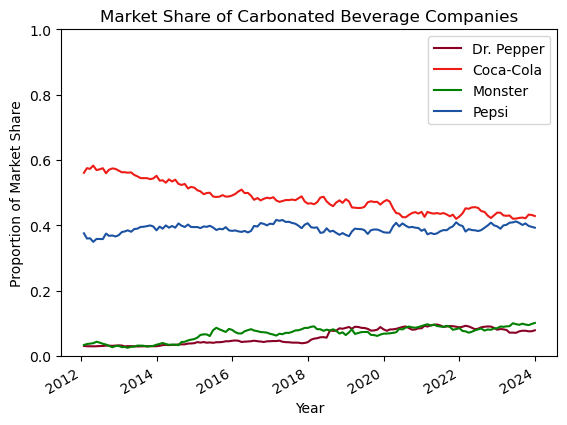

In [10]:
# Plot the data
fig, ax = plt.subplots()
port.columns = ["Dr. Pepper", "Coca-Cola", "Monster", "Pepsi"]
port.plot(color=['#890024', '#ed1c16', 'green', '#1b52a2'], ax=ax)
plt.ylim([0.0, 1.0])
plt.ylabel("Proportion of Market Share")
plt.xlabel("Year")
plt.title("Market Share of Carbonated Beverage Companies")
plt.legend(loc='upper right')
plt.show()

In [11]:
# Calculate the rolling correlations
window_size = 6
rolling_correlations = {}
for i in port2.columns:
    for j in port2.columns:
        if j != i:  
            rolling_correlations[j] = port2[i].rolling(window=window_size).corr(port2[j])

# Set all of the rolling correlation values to the dataframe as the beta values
port2["beta_KO_PEP"] = port2["KO"].rolling(window=window_size).corr(port2["PEP"])
port2["beta_KO_Other"] = port2["KO"].rolling(window=window_size).corr(port2["Other"])

port2["beta_PEP_KO"] = port2["PEP"].rolling(window=window_size).corr(port2["KO"]) #COPY
port2["beta_PEP_Other"] = port2["PEP"].rolling(window=window_size).corr(port2["Other"])

port2["beta_Other_KO"] = port2["Other"].rolling(window=window_size).corr(port2["KO"]) #COPY
port2["beta_Other_PEP"] = port2["Other"].rolling(window=window_size).corr(port2["PEP"]) #COPY


# Set all of the exponential weighted moving average values to the dataframe as alphas
port2["alpha_KO"] = port2["KO"].ewm(span=window_size, min_periods=window_size).mean()
port2["alpha_PEP"] = port2["PEP"].ewm(span=window_size, min_periods=window_size).mean()
port2["alpha_Other"] = port2["Other"].ewm(span=window_size, min_periods=window_size).mean()
port2

ticker,KO,PEP,Other,beta_KO_PEP,beta_KO_Other,beta_PEP_KO,beta_PEP_Other,beta_Other_KO,beta_Other_PEP,alpha_KO,alpha_PEP,alpha_Other
caldt,,,,,,,,,,,,
2012-01-31,0.560856,0.375433,0.063711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-02-29,0.574936,0.359477,0.065587,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-03-30,0.573049,0.360135,0.066816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-04-30,0.582975,0.349198,0.067827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-05-31,0.569099,0.358212,0.072688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,0.423583,0.400983,0.175434,-0.477287,-0.512300,-0.477287,-0.510160,-0.512300,-0.510160,0.424820,0.404579,0.170601
2023-09-29,0.421522,0.405682,0.172796,-0.208766,-0.640619,-0.208766,-0.617200,-0.640619,-0.617200,0.423878,0.404894,0.171228
2023-10-31,0.432805,0.397820,0.169376,-0.851855,-0.116942,-0.851855,-0.420566,-0.116942,-0.420566,0.426428,0.402873,0.170699


In [12]:
# Set the arrays for the initial conditions
y0 = np.array(port2.query('caldt == "2012-06-29"'))[0][:3]
alphas = np.array(port2.query('caldt >= "2012-06-29"')[["alpha_KO",	"alpha_PEP", "alpha_Other"]])
KO_alpha = alphas[:,0]
PEP_alpha = alphas[:,1]
Other_alpha = alphas[:,2]

# Set the arrays for the betas
KO_betas = np.array(port2.query('caldt >= "2012-06-29"')[["beta_KO_PEP","beta_KO_Other"]])
PEP_betas = np.array(port2.query('caldt >= "2012-06-29"')[["beta_PEP_KO","beta_PEP_Other"]])
Other_betas = np.array(port2.query('caldt >= "2012-06-29"')[["beta_Other_KO","beta_Other_PEP"]])
betas = np.array([KO_betas, PEP_betas, Other_betas])

/var/folders/nm/jgfv46_n3kg1pc1ltp9d95vm0000gn/T/ipykernel_92296/840619416.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  y0 = np.array(port2.query('caldt == "2012-06-29"'))[0][:3]


In [13]:
# Define the ODE
def final_ode(t, y, alphas, betas):
    
    # Define the alpha and beta values
    alpha = alphas[int(t)] 
    alpha[0] = alpha[0] / 10
    alpha[1] = alpha[1] / 10 
    alpha[2] = alpha[2] / 10
    betas = betas / 100
    
    # Define the carrying capacity
    K = 2/3
    dydt = np.zeros(3)
    
    # Iterate through the companies
    for i in range(3):
        competitive_term = np.sum([betas[i][int(t)][j] * y[j] for j in range(2)])
        dydt[i] = y[i] * (alpha[i] * (1 - y[i] / K) - competitive_term)

    return dydt

In [14]:
# Define the time and space
t0 = 0
tf = 138
x_space = np.linspace(t0, tf, 1000)

# Define y0 and solution
sol = solve_ivp(final_ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000), args=[alphas, betas])
sol.y = sol.y / np.sum(sol.y, axis=0)

In [15]:
# Create port2
port2 = np.array(port2.query('caldt >= "2012-06-29"'))[:, :3]


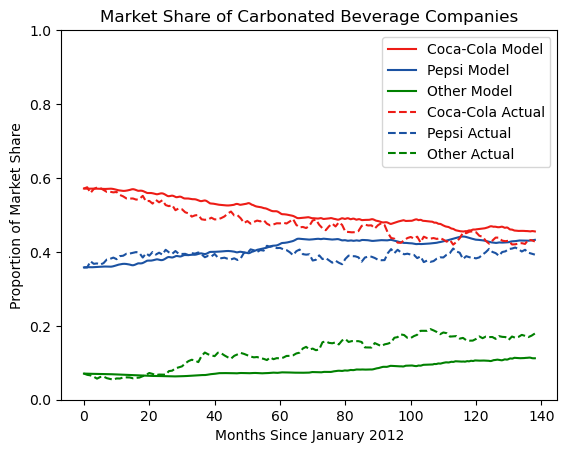

In [16]:
# Plot the system
plt.plot(sol.t, sol.y[0], color = '#ed1c16', ls = '-', label=f"Coca-Cola Model")
plt.plot(sol.t, sol.y[1], color = '#1b52a2', ls = '-', label=f"Pepsi Model")
plt.plot(sol.t, sol.y[2],  color = 'green', ls = '-', label=f"Other Model")
plt.plot(np.linspace(t0, tf, 139), port2[:, 0], color = '#ed1c16', ls = '--', label=f"Coca-Cola Actual")
plt.plot(np.linspace(t0, tf, 139), port2[:, 1], color = '#1b52a2', ls = '--', label=f"Pepsi Actual")
plt.plot(np.linspace(t0, tf, 139), port2[:, 2],  color = 'green', ls = '--', label=f"Other Actual")

# Add labels and legend
plt.ylabel("Proportion of Market Share")
plt.xlabel("Months Since January 2012")
plt.title("Market Share of Carbonated Beverage Companies")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [17]:
# Set the arrays for the initial conditions
fake_alp= np.array([KO_alpha.mean(), PEP_alpha.mean(), Other_alpha.mean()]) 
betas = np.array([[1, -.64, -.41],
          [-.64, 1, -.26],
          [-.41, -.26, 1]]) / 100

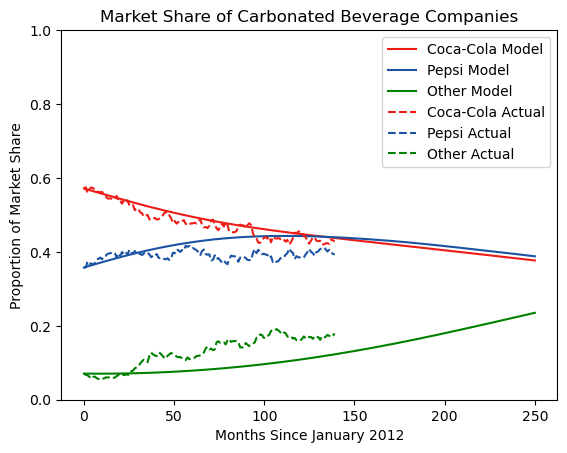

In [18]:
# Define the ODE
def event_based_model():
    
    # Define the ODE and carrying capacity
    K = 2/3
    def ode(t, y):
        
        # Initialize
        dydt = np.zeros(3)
        temporary_alpha = fake_alp.copy() 
        
        # Iterate through the companies 
        for i in range(3):
            competitive_term = np.sum([betas[i, j] * y[j] for j in range(3) if j != i])
            dydt[i] = y[i] * (temporary_alpha[i] * (1 - y[i] / K) - competitive_term)
        return dydt

    # Define the time and space
    t0 = 0
    tf = 250
    x_space = np.linspace(0, tf, 1000)
    
    #Define y0 and solution
    sol = solve_ivp(ode, (t0, tf), y0, t_eval=np.linspace(t0, tf, 1000))
    sol.y = sol.y / np.sum(sol.y, axis=0)
    
    #Plot the system
    plt.plot(sol.t, sol.y[0], color = '#ed1c16', ls = '-', label=f"Coca-Cola Model")
    plt.plot(sol.t, sol.y[1], color = '#1b52a2', ls = '-', label=f"Pepsi Model")
    plt.plot(sol.t, sol.y[2],  color = 'green', ls = '-', label=f"Other Model")
    plt.plot(np.linspace(t0, 139, 139), port2[:, 0], color = '#ed1c16', ls = '--', label=f"Coca-Cola Actual")
    plt.plot(np.linspace(t0, 139, 139), port2[:, 1], color = '#1b52a2', ls = '--', label=f"Pepsi Actual")
    plt.plot(np.linspace(t0, 139, 139), port2[:, 2],  color = 'green', ls = '--', label=f"Other Actual")

    # Add labels and legend
    plt.ylabel("Proportion of Market Share")
    plt.xlabel("Months Since January 2012")
    plt.title("Market Share of Carbonated Beverage Companies")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    
    # Return the solution
    return sol.y, fake_alp, betas
    
solution = event_based_model()

In [19]:
# Set the arrays for the initial conditions
# df = pd.read_csv('crsp_monthly.csv',parse_dates=True)
df = pd.read_feather("crsp_monthly.ftr")
df = df[df['cusip'].isin(['15118V20'])].sort_values('caldt')
df

,permno,caldt,cusip,ticker,shrcd,excd,siccd,prc,ret,vol,shr,cumfacshr
4871292,93263,2017-05-31,15118V20,CELH,11,3,1000,4.07000,NaN,6076.0,44102.0,3.0
4871293,93263,2017-06-30,15118V20,CELH,11,3,1000,4.25000,0.044226,10864.0,45340.0,3.0
4871294,93263,2017-07-31,15118V20,CELH,11,3,1000,3.91990,-0.077671,8044.0,45340.0,3.0
4871295,93263,2017-08-31,15118V20,CELH,11,3,1000,4.84000,0.234725,17929.0,45340.0,3.0
4871296,93263,2017-09-29,15118V20,CELH,11,3,1000,5.91000,0.221074,35627.0,45679.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4871367,93263,2023-08-31,15118V20,CELH,11,3,1000,196.03999,0.354803,331783.0,76891.0,3.0
4871368,93263,2023-09-29,15118V20,CELH,11,3,1000,171.60001,-0.124668,237095.0,77225.0,3.0
4871369,93263,2023-10-31,15118V20,CELH,11,3,1000,152.09000,-0.113695,253078.0,77225.0,3.0
4871370,93263,2023-11-30,15118V20,CELH,11,3,1000,49.51000,-0.023407,893666.0,231675.0,1.0


In [20]:
# Account for the missing data
# df = pd.read_csv('crsp_monthly.csv',parse_dates=True)
df = pd.read_feather("crsp_monthly.ftr")
df['caldt'] = pd.to_datetime(df['caldt'])
#df = df[df['permno'].isin([13856,11308,88031,93263,17942,91988])]
df = df[df['cusip'].isin(['49271V10','71344810','61174X10','19121610','15118V20','26138E10'])]

# Perform the necessary data cleaning
mask1 = df['cusip'] == '26138E10'
df['cusip'][mask1] = '49271V10'
df[df['ticker'].isin(['KDP'])]
df = df.query("'2017-05-31' <= caldt <= '2023-01-01'")
df = df.sort_values('caldt').reset_index()

# Calculate the market share
df['MS'] = df.prc * df.shr
df['MS_total'] = df['caldt'].map(df.groupby('caldt')['MS'].sum())
df.groupby('cusip')['caldt'].min()

/var/folders/nm/jgfv46_n3kg1pc1ltp9d95vm0000gn/T/ipykernel_92296/2222749771.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['cusip'][mask1] = '49271V10'


cusip
15118V20   2017-05-31
19121610   2017-05-31
49271V10   2017-05-31
61174X10   2017-05-31
71344810   2017-05-31
Name: caldt, dtype: datetime64[ns]

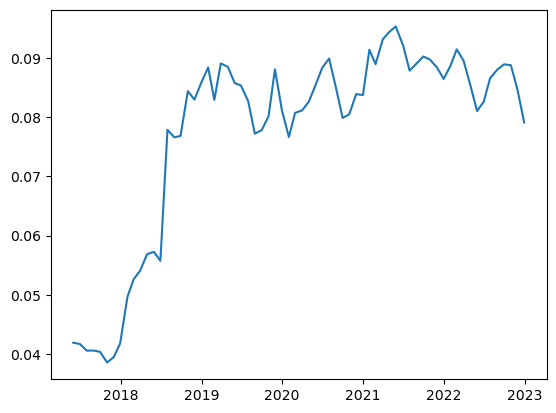

In [21]:
# Calculate the market share
df['pms'] = df.MS / df.MS_total
stonks = df['cusip'].unique()

# Plot the data
dp = df[df.cusip == '49271V10']
plt.plot(dp['caldt'],dp['pms'])

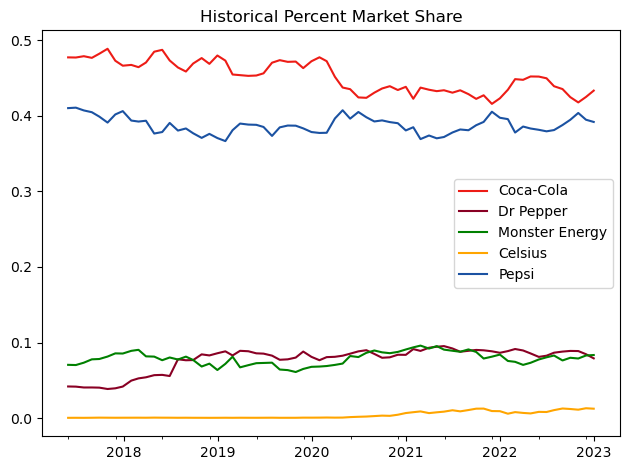

In [22]:
# Plot the data
df['pms'] = df.MS / df.MS_total
stonks = df['cusip'].unique()

# Itialize the names and colors
names = ['Coca-Cola', 'Dr Pepper','Monster Energy', 'Celsius', 'Pepsi']
colors = ['#ed1c16','#890024','green', 'orange', '#1b52a2']

# Plot the data
for stonk,name,color in zip(stonks,names,colors):
    df1 = df[df.cusip == stonk]
    plt.plot(df1.caldt, df1.pms, label = name,color = color)

# Add labels and legend
plt.title('Historical Percent Market Share')
plt.legend()
plt.gca().xaxis.set_major_locator(dates.YearLocator(1))  # Ticks every year
plt.gca().xaxis.set_minor_locator(dates.MonthLocator(interval=6))  # Minor ticks every 6 months
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%Y'))  # Format major ticks as years

# Plot the data
plt.tight_layout()
plt.show()

# Previous modeling attempts and failures :)

### Projecting the solution at each step on to the simplex constraint

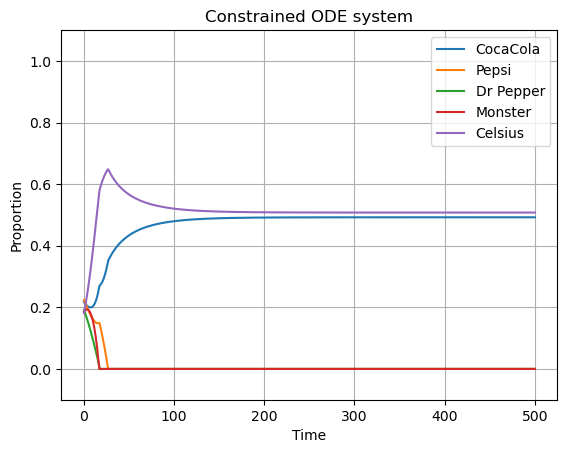

All 1 check: True
[0.49231528 0.         0.         0.         0.50768472]


In [23]:
def original_ode(t, X, alpha, beta, K):
    """Define the unconstrained ODE system."""
    n = len(X)  # num companies
    dXdt = np.zeros(n)
    for i in range(n):
        competition = np.sum(beta[i, :] * X) - beta[i, i] * X[i]  # competition term, excluding self-competition
        growth = X[i] * alpha[i] * (1 - X[i] / K)  # logistic growth term
        dXdt[i] = growth - competition
    return dXdt


def regularized_ode(t, X, alpha, beta, K, epsilon=1e-3):
    """Define the unconstrained ODE system with a regularization term."""
    n = len(X)  # num companies
    dXdt = np.zeros(n)
    for i in range(n):
        competition = np.sum(beta[i, :] * X) - beta[i, i] * X[i]
        growth = X[i] * alpha[i] * (1 - X[i] / K)
        dXdt[i] = growth - competition - epsilon * X[i]
    return dXdt


def project_to_simplex(X):
    """Project a vector onto the simplex sum(X) = 1, X >= 0.
    Follows algorithm 1. From https://stanford.edu/~jduchi/projects/DuchiShSiCh08.pdf
    """
    n = len(X)
    X_sorted = np.sort(X)[::-1]  # sort in descending order
    cumsum = np.cumsum(X_sorted)
    rho = np.where(X_sorted > (cumsum - 1) / np.arange(1, n + 1))[0][-1]  # find the largest index such that X_sorted > (cumsum - 1) / i
    theta = (cumsum[rho] - 1) / (rho + 1)  # (rho + 1) because rho is 0-indexed
    return np.maximum(X - theta, 0)

def project_to_truncated_simplex(X, K):
    """Project a vector onto the simplex with 0 <= X <= K."""
    X_clipped = np.minimum(X, K)  # first enforce the upper bound
    return project_to_simplex(X_clipped)  # then project onto the simplex

def solve(alpha, beta, K, X0, t):
    """Solve the constrained ODE system.
    The idea is that we solve the unconstrained ODE system, and then project the solution onto the simplex.
   So far uses a simple Forward Euler method.
   """
    n = len(X0)
    dt = t[1] - t[0]  # time step
    X = np.zeros((n, len(t)))  # store the solution here
    
    X0 = project_to_simplex(X0)  # project the initial condition onto the simplex if not already in it
    X[:, 0] = X0  # initial condition

    # Solve with RK4
    for i in range(1, len(t)):
        k1 = regularized_ode(t[i-1], X[:, i-1], alpha, beta, K)
        k2 = regularized_ode(t[i-1] + dt/2, X[:, i-1] + dt/2 * k1, alpha, beta, K)
        k3 = regularized_ode(t[i-1] + dt/2, X[:, i-1] + dt/2 * k2, alpha, beta, K)
        k4 = regularized_ode(t[i-1] + dt, X[:, i-1] + dt * k3, alpha, beta, K)
        X[:, i] = project_to_simplex(X[:, i-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4))
    
    return X


def wrapped_ode(t, X):
    """Wrap the ODE system to include the parameters."""
    return project_to_simplex(original_ode(t, X, alpha, beta, K))


# Define the parameters
n = 5
alpha = np.array([0.0297, 0.0033, 0.027, 0.1038, .1936]) 

beta = np.array([
    [0, 9, 8, 1, 1], 
    [9, 0, 8, 1, 1], 
    [8, 8, 0, 2, 2],
    [5, 5, 2, 0, 8],
    [5, 5, 2, 8, 0]
]) / 100


np.fill_diagonal(beta, 0)
K = 2/3
X0 = np.array([0.369, 0.44, 0.12, 0.059, 0.011]) / 10
t = np.linspace(0, 500, 1000)

# Solve the system
X = solve(alpha, beta, K, X0, t)

sol = solve_ivp(wrapped_ode, [0, 1000], X0, t_eval=t)

idx2company = ['CocaCola', 'Pepsi', 'Dr Pepper', 'Monster', 'Celsius']

for i in range(n):
    plt.plot(t, X[i, :], label=f'{idx2company[i]}')


plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.xlabel('Time')
plt.ylabel('Proportion')
plt.title('Constrained ODE system')
plt.show()

all_1_check = np.allclose(X.sum(axis=0), 1)
if not all_1_check:
    print(X[:, -1].sum())
print(f'All 1 check: {all_1_check}')

print(X[:, -1])  # final proportions

# Stability Analysis

In [26]:
# Find the equilibrium solutions of the following system of equations:
# Replace these with other values as desired
K = 2/3
alpha = np.array([0.024, 0.0185, 0.0047])
beta = np.array([
    [0.00, -0.0064, -0.0041],
    [-0.0064, 0.00, -0.0026],
    [-0.0041, -0.0026, 0.00]
])


# Define the system of equations
def equations(X):
    X1, X2, X3 = X

    eq1 = X1 * (alpha[0] * (1 - X1 / K) + beta[0, 1] * X2 + beta[0, 2] * X3)
    eq2 = X2 * (alpha[1] * (1 - X2 / K) + beta[1, 0] * X1 + beta[1, 2] * X3)
    eq3 = X3 * (alpha[2] * (1 - X3 / K) + beta[2, 0] * X1 + beta[2, 1] * X2)

    return [eq1, eq2, eq3]


# Solve the system of equations
X1, X2, X3 = sp.symbols('X_1 X_2 X_3')
solution = sp.solve(equations([X1, X2, X3]), [X1, X2, X3], dict=True)

print('Equilibrium solutions:')
for sol in solution:
    sol = {k: round(v, 2) for k, v in sol.items()}
    print(sol)
print(f"\nTotal of {len(solution)} solutions found.")

Equilibrium solutions:
{X_1: 0.0, X_2: 0.0, X_3: 0.0}
{X_1: 0.0, X_2: 0.0, X_3: 0.67}
{X_1: 0.0, X_2: 0.63, X_3: 0.44}
{X_1: 0.0, X_2: 0.67, X_3: 0.0}
{X_1: 0.56, X_2: 0.52, X_3: 0.15}
{X_1: 0.57, X_2: 0.53, X_3: 0.0}
{X_1: 0.63, X_2: 0.0, X_3: 0.30}
{X_1: 0.67, X_2: 0.0, X_3: 0.0}

Total of 8 solutions found.


In [27]:
# analyze the stability of the equilibrium points

# Define the Jacobian matrix
def jacobian(X):
    X1, X2, X3 = X
    J = np.zeros((3, 3))

    # Diagonal terms (i = j)
    J[0, 0] = alpha[0] * (1 - 2 * X1 / K) + beta[0, 1] * X2 + beta[0, 2] * X3
    J[1, 1] = alpha[1] * (1 - 2 * X2 / K) + beta[1, 0] * X1 + beta[1, 2] * X3
    J[2, 2] = alpha[2] * (1 - 2 * X3 / K) + beta[2, 0] * X1 + beta[2, 1] * X2

    # Off-diagonal terms (i ≠ j)
    J[0, 1] = beta[0, 1] * X1
    J[0, 2] = beta[0, 2] * X1
    J[1, 0] = beta[1, 0] * X2
    J[1, 2] = beta[1, 2] * X2
    J[2, 0] = beta[2, 0] * X3
    J[2, 1] = beta[2, 1] * X3

    return J


equilibrium_points = []
for sol in solution:
    X1, X2, X3 = sol.values()
    X1, X2, X3 = float(X1), float(X2), float(X3)
    J = jacobian([X1, X2, X3])

    # Handle edge cases
    if np.allclose(J, 0):  # Check if J is an all-zero matrix
        eigenvalues = np.zeros(J.shape[0])
    else:
        eigenvalues = np.linalg.eigvals(J)
    
    if not np.allclose([X1, X2, X3], 0.0):
        print(f"Eigenvalues for equilibrium point {sol}: {eigenvalues}")

    # Classify equilibrium
    if all(eigenvalue < 0 for eigenvalue in eigenvalues.real):  # Use .real for stability
        equilibrium_points.append((sol, 'stable'))
    elif all(eigenvalue > 0 for eigenvalue in eigenvalues.real):
        equilibrium_points.append((sol, 'unstable'))
    else:
        equilibrium_points.append((sol, 'saddle'))

        equilibrium_points.append((sol, 'saddle'))

# Print the stability of the equilibrium points
print('\nStability of equilibrium points:')
for sol, stability in equilibrium_points:
    sol = {k: round(v, 2) for k, v in sol.items()}
    print(f'{sol}: {stability}')

Eigenvalues for equilibrium point {X_1: 0.0, X_2: 0.0, X_3: 0.666666666666667}: [-0.0047      0.02126667  0.01676667]
Eigenvalues for equilibrium point {X_1: 0.0, X_2: 0.625828910272531, X_3: 0.435864515360485}: [-0.00294498 -0.01749461  0.01820765]
Eigenvalues for equilibrium point {X_1: 0.0, X_2: 0.666666666666667, X_3: 0.0}: [-0.0185      0.01973333  0.00296667]
Eigenvalues for equilibrium point {X_1: 0.556403648884832, X_2: 0.524315126256059, X_3: 0.149719959050559}: [-0.02179355 -0.01288054 -0.00096171]
Eigenvalues for equilibrium point {X_1: 0.571583649951985, X_2: 0.534841969020083, X_3: 0.0}: [-0.02226408 -0.0131548   0.00096592]
Eigenvalues for equilibrium point {X_1: 0.632642727541247, X_2: 0.0, X_3: 0.298746782564665}: [-0.02292772 -0.00195358  0.01367434]
Eigenvalues for equilibrium point {X_1: 0.666666666666667, X_2: 0.0, X_3: 0.0}: [-0.024       0.01423333  0.00196667]

Stability of equilibrium points:
{X_1: 0.0, X_2: 0.0, X_3: 0.0}: unstable
{X_1: 0.0, X_2: 0.0, X_3: 0.6